# Harmonize data with neuroComBat

## Importing necesary moduls

In [ ]:
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import structlog

from uniharmony.combat import NeuroComBat
from uniharmony.datasets import make_multisite_classification


# To only get the necessary info from structlog, we configure it to filter out messages below INFO level.
structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.INFO))

## Generate data using `unharmony` function

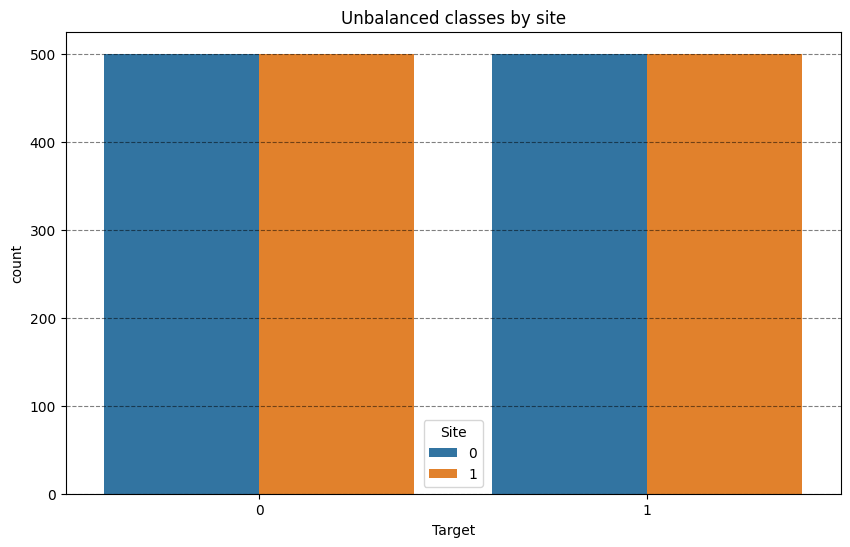

In [29]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=2000,
    n_sites=2,
    n_features=2,
)
df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

## Let's create a instance of the neuroCombat harmonizer

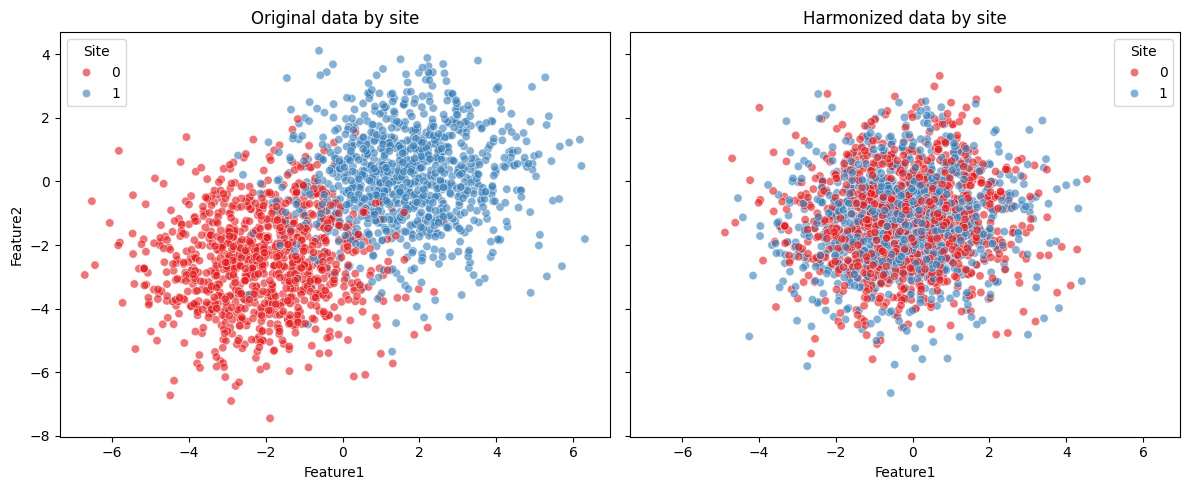

In [30]:
combat = NeuroComBat()
X_harmonized = combat.fit_transform(X, sites)
df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Phase"] = "Harmonized"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", palette="Set1", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", palette="Set1", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
plt.tight_layout()

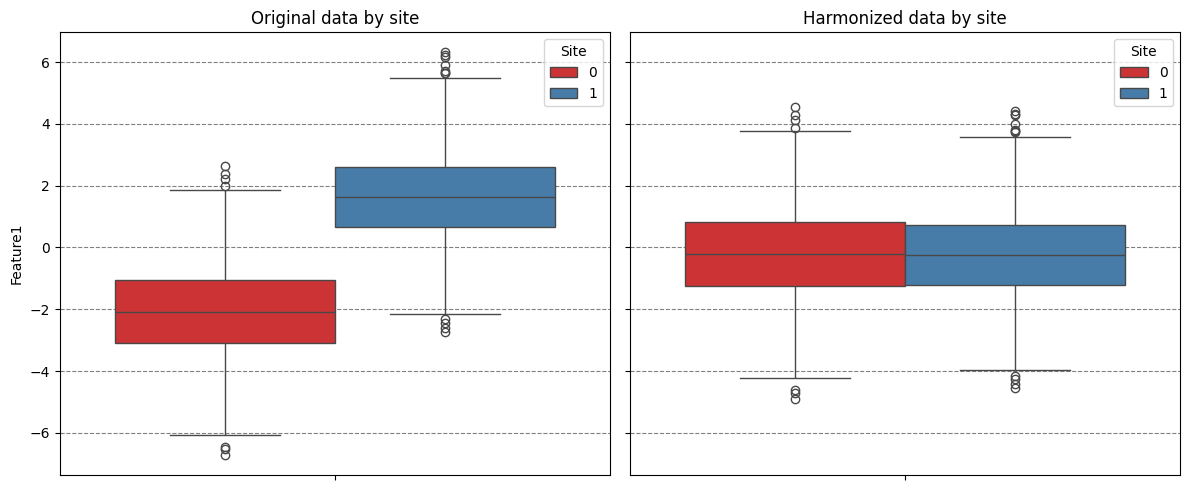

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.boxplot(data=df_orig, y="Feature1", hue="Site", palette="Set1", ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(axis="y", color="black", alpha=0.5, linestyle="--")
sns.boxplot(data=df_harm, y="Feature1", hue="Site", palette="Set1", ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()

# Take Home message
As expected, neuroComBat pushes the mean of the site distributions (-2 and +2) closer to the overall feature average (0).